# Estratégia de Retenção de Clientes: Análise de Rotatividade Model Fitness

Data: 08/04/2026

Autor: Fabrício Camacho

## 1 Introdução
A rede de academias Model Fitness está focada em digitalizar os perfis de seus clientes para combater a rotatividade. O desafio principal é que muitos clientes "saem de fininho", parando de frequentar sem cancelar formalmente o contrato. Para esta análise, consideramos que um cliente deu churn se não apareceu na unidade por um mês inteiro. 
### 1.1 Objetivos do Projeto
O objetivo deste estudo é analisar os dados dos clientes e desenvolver uma estratégia de retenção baseada em dados.  As etapas principais incluem:
- **Análise Exploratória de Dados (AED)**: Estudar o perfil dos clientes que ficam versus os que saem.
- **Modelagem Preditiva**: Treinar modelos de classificação binária para prever a probabilidade de rotatividade para o mês seguinte.
- **Agrupamento (Clustering)**: Identificar grupos (clusters) de usuários típicos para entender seus comportamentos e lealdade.
- **Recomendações**: Propor ações de marketing e mudanças no serviço para diminuir a rotatividade.
### 1.2 Descrição dos Dados
O conjunto de dados contém informações sobre o mês atual (churn) e o histórico do mês anterior, incluindo:
- **Perfil**: Gênero, proximidade da unidade, parceria com empresas, indicação de amigos e telefone.
- **Uso**: Idade, tempo de vida do cliente (lifetime), período do contrato, frequência de visitas e gastos adicionais.
## 2 Importação de Bibliotecas e Carregando Dados

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

# Carregando o conjunto de dados
# O caminho do arquivo foi especificado nas instruções do projeto [cite: 51]
try:
    df_gym_churn = pd.read_csv('datasets/gym_churn_us.csv')
    print("Dados carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Arquivo não encontrado. Verifique o caminho do dataset.")

# Visualização inicial para confirmar se os dados estão corretos
display(df_gym_churn.info())
display(df_gym_churn.head())



Dados carregados com sucesso!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total 

None

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


### 2.1 Padronizando Informações
Aqui modificaremos os nomes das colunas para padrão snake_case.

In [19]:
# Convertendo os nomes das colunas para snake_case (letras minúsculas)
df_gym_churn.columns = [i.lower() for i in df_gym_churn.columns]

# Visualizando as primeiras linhas com o novo padrão
df_gym_churn.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

## 3 Análise Explanatória dos Dados
Nesta etapa, buscaremos padrões que diferenciem os clientes leais daqueles que abandonaram a academia.
### 3.1 Inspeção Inicial e Estatísticas Descritivas
Primeiro, vamos verificar a integridade dos dados e as estatísticas gerais de cada característica.

In [20]:
# Verificando valores ausentes e tipos de dados
print(df_gym_churn.info())

# Estatísticas descritivas gerais
display(df_gym_churn.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


**Observações:** Com essas informações é possível observar que:
- O conjunto de dados possui $4.000$ entradas e todas as colunas estão preenchidas ($4.000$ non-null). Dessa maneira não precisaremos de técnicas de imputação.
- A média da coluna `churn` é $0,265$, o que significa que aproximadamente $26,5\%$ dos clientes deixaram a academia no mês em questão. Esse é o principal indicador a ser reduzido.
- Cerca de $84,5\%$ dos clientes moram ou trabalham perto da academia (`near_location`), o que sugere que a localização é um fator forte de adesão.
- Quase metade ($48,6\%$) são funcionários de empresas parceiras (`partner`) e $30,8\%$ vieram através da promoção "traga um amigo" (promo_friends).
- A idade média é de aproximadamente $29$ anos (variando de $18$ a $41$), indicando um público jovem e adulto.
- Os clientes frequentam a academia, em média, $1,88$ vezes por semana ao longo de todo o tempo de contrato.
- A média de tempo de vida (`lifetime`) é de $3,7$ meses, mas o desvio padrão é alto ($3,74$). O valor máximo de $31$ meses mostra que existem clientes muito leais, mas o $25º$ percentil em $1$ mês indica que muitos saem logo no início.
- A média de duração do contrato (`contract_period`) é de $4,68$ meses, mas a mediana ($50\%$) é de apenas $1$ mês. Isso mostra que a maioria dos clientes opta por planos mensais, que costumam ter maior rotatividade.

### 3.2 Comparação de Médias entre Grupos
Agora vamos comparar as médias de cada uma das variáveis entre os clientes que sairam e os que ficaram na academia.


In [21]:
# Observando as médias dos valores das características para os dois grupos: 
# os que ficaram (churn=0) e os que saíram (churn=1)
churn_comparison = df_gym_churn.groupby('churn').mean().T
display(churn_comparison)

churn,0,1
gender,0.510037,0.510839
near_location,0.873086,0.768143
partner,0.534195,0.355325
promo_friends,0.353522,0.183789
phone,0.903709,0.902922
contract_period,5.747193,1.728558
group_visits,0.464103,0.268615
age,29.976523,26.989632
avg_additional_charges_total,158.445715,115.082899
month_to_end_contract,5.283089,1.662582


**Observações**: Ao comparar médias entre aqueles que saem (churn=0) e aqueles que ficam (churn=1), é possível observar:
- No último mês (`avg_class_frequency_current_month`), quem saiu frequentou apenas 1 vez por semana em média, enquanto quem ficou manteve 2 vezes. Uma queda na frequência é um sinal de alerta crítico. 
- Quem sai tem, em média, menos de $1$ mês de histórico (0.99). Isso indica que o período de maior risco é logo após a matrícula. 
- Quem fica tem contratos muito mais longos (média de $5,7$ meses) contra apenas $1,7$ meses de quem sai. Contratos anuais parecem segurar muito mais o cliente. 
- Clientes que vêm de empresas parceiras (`partner`) ou indicação de amigos (promo_friends) têm taxas de rotatividade menores.

### 3.3 Distribuições e Histogramas
Aqui vamos criar histogramas de barra e distribuições para visualizar esses dados.  Isso ajudará a ver se os grupos se sobrepõem ou se são totalmente distintos.

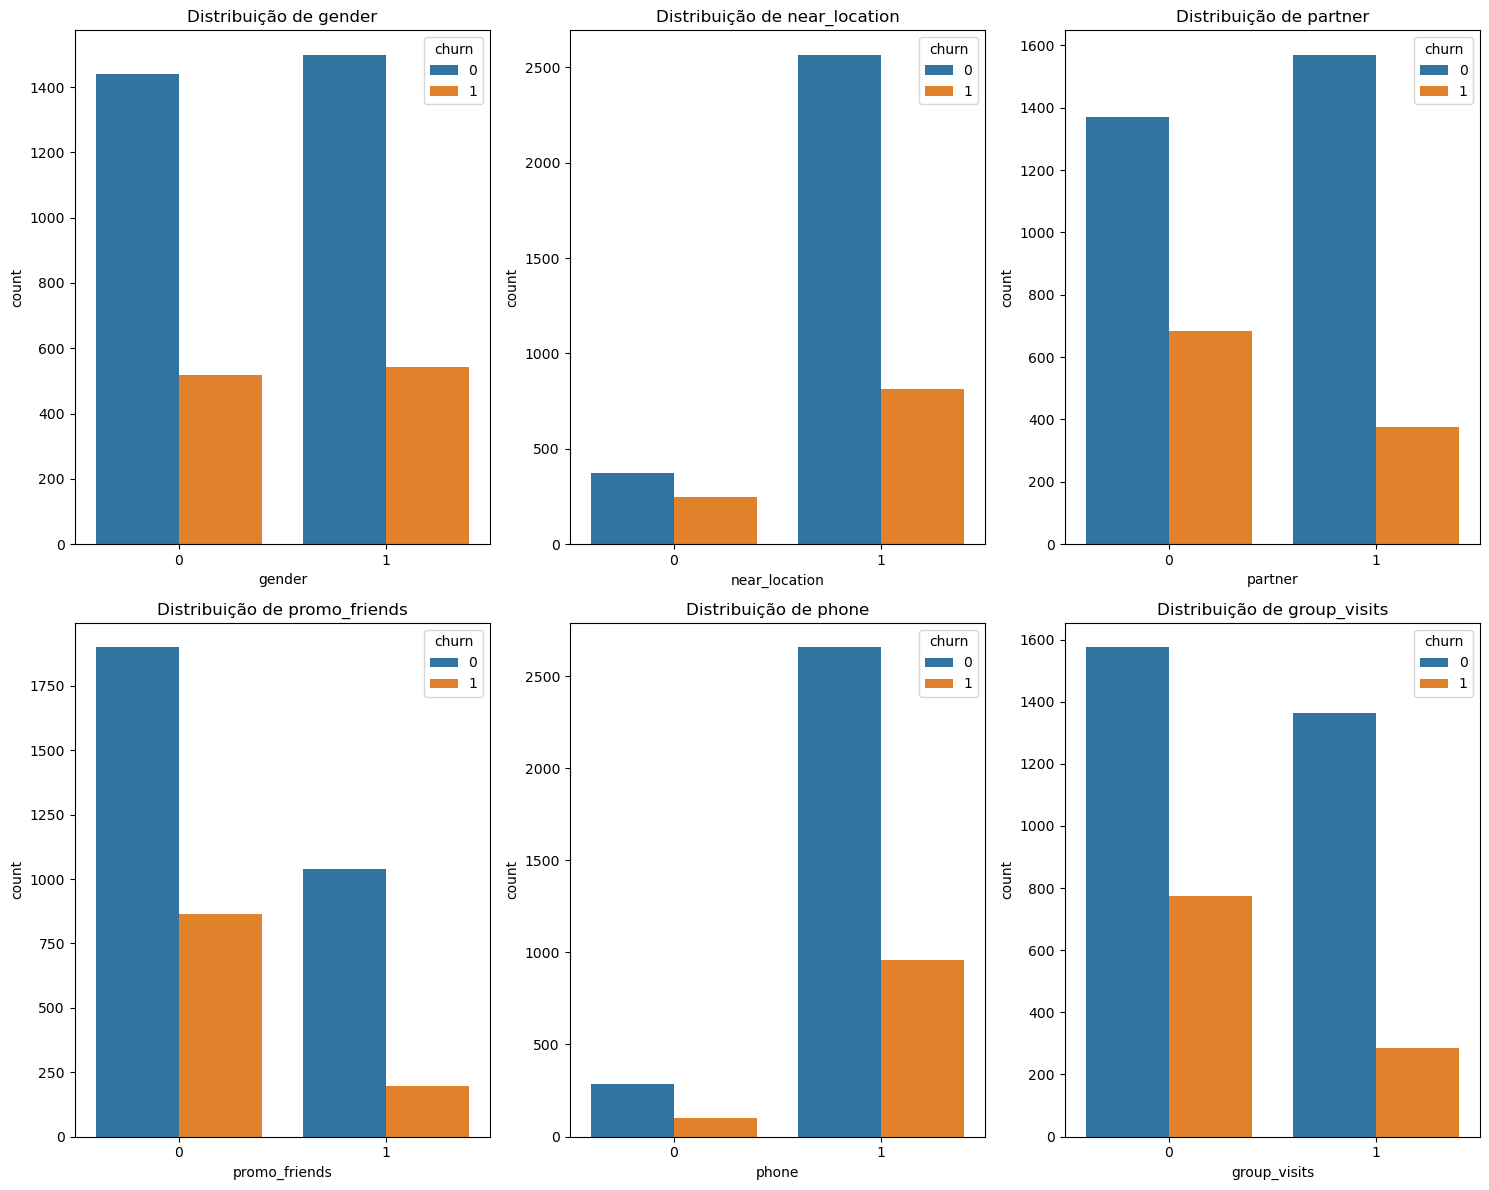

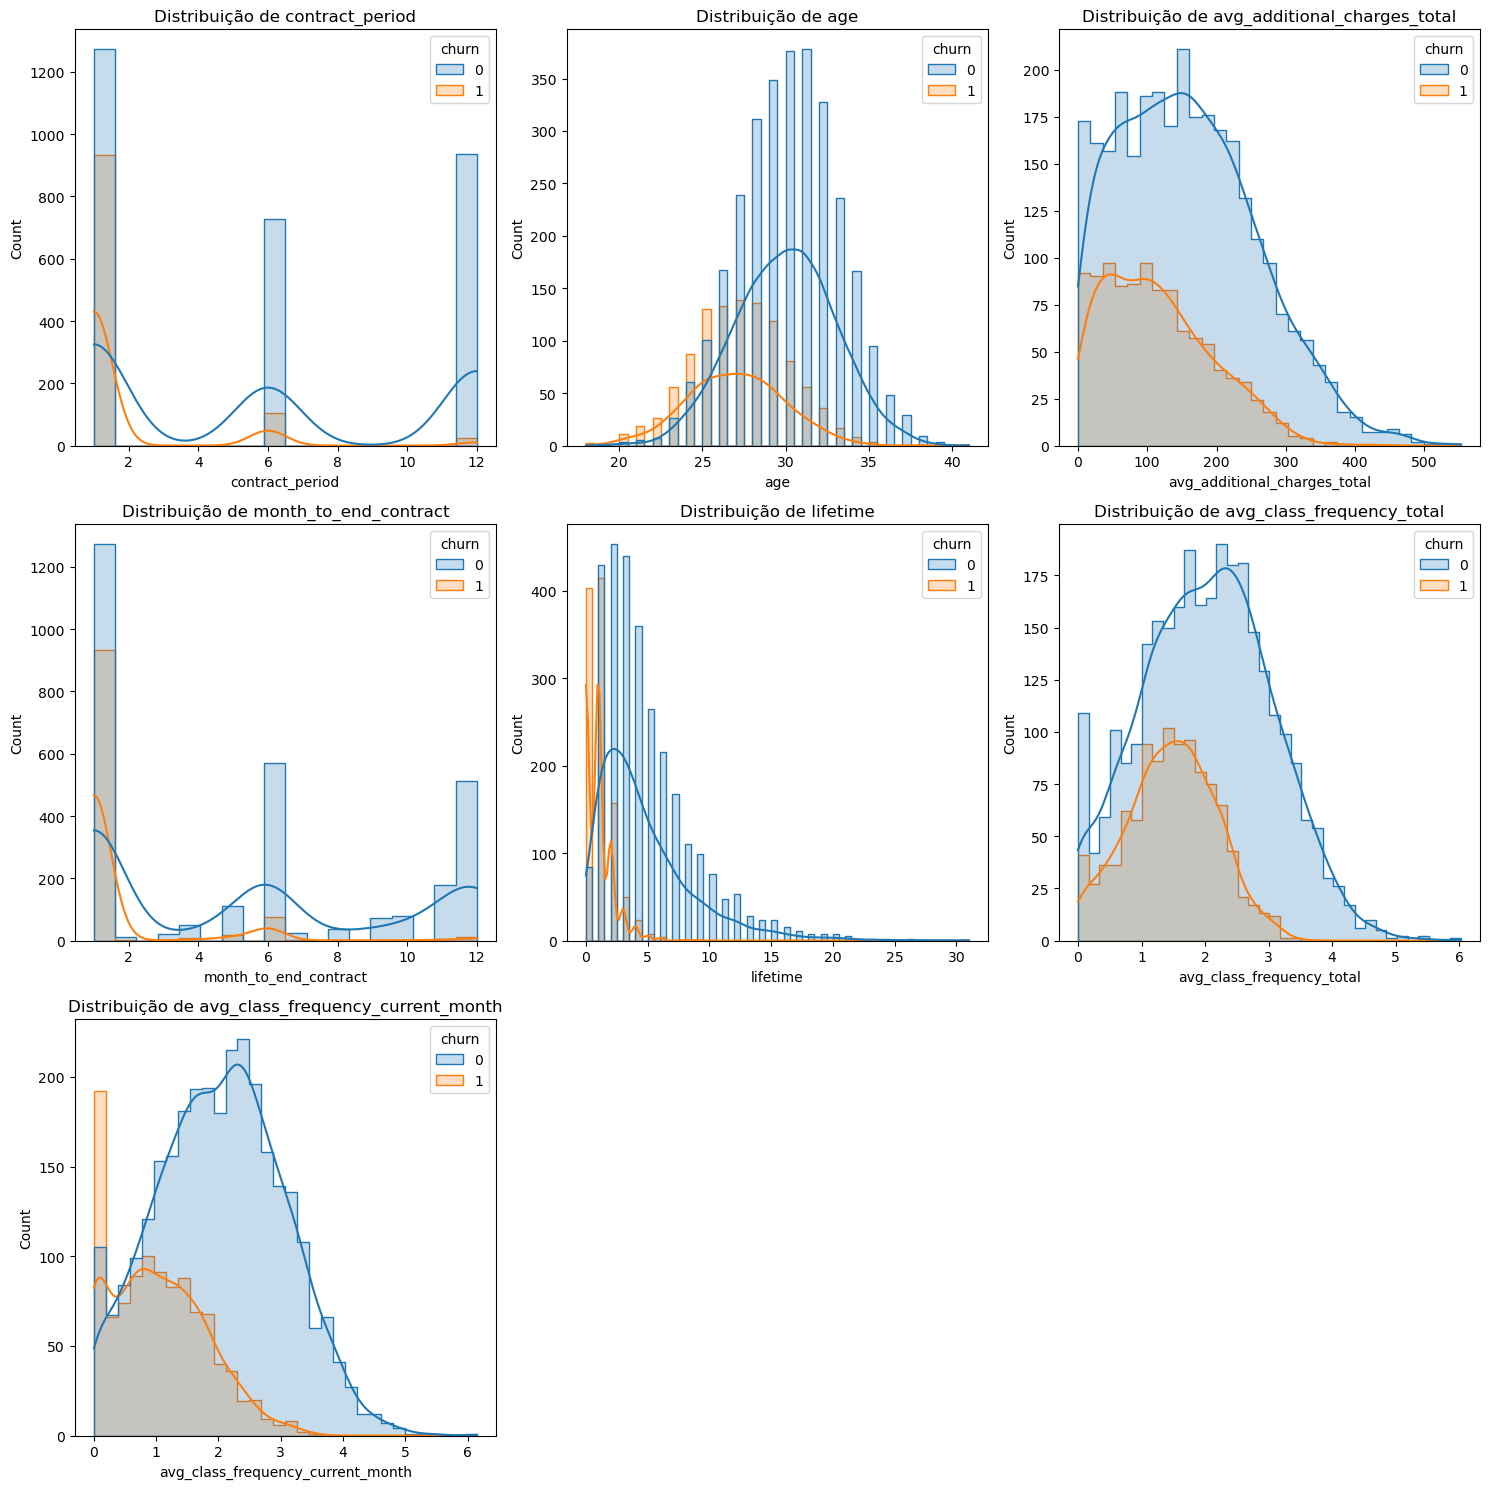

In [22]:
# Definindo as colunas para plotagem (dividindo entre binárias e numéricas para melhor visualização)
binary_cols = ['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'group_visits']
numeric_cols = ['contract_period', 'age', 'avg_additional_charges_total', 
                'month_to_end_contract', 'lifetime', 
                'avg_class_frequency_total', 'avg_class_frequency_current_month']

# Plotando variáveis binárias (Gráficos de Barra)
plt.figure(figsize=(15, 12))
for i, col in enumerate(binary_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df_gym_churn, x=col, hue='churn')
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

# Plotando variáveis numéricas (Histogramas/KDE)
plt.figure(figsize=(15, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=df_gym_churn, x=col, hue='churn', kde=True, element="step")
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()


**Observações**: Os gráficos confirmam visualmente o que a análise das médias já comunicava. Isso torna o perfil do cliente que sai muito mais bem definido:
- **Ponto Crítico (Lifetime)**: O histograma de `lifetime` é o mais impactante. O churn está concentrado quase inteiramente no mês $0$ e $1$. Se o cliente sobrevive aos primeiros $3$ meses, a chance de ele sair cai drasticamente;
- **Frequência**: No gráfico `avg_class_frequency_current_month`, vemos que quem tem churn costuma frequentar de $0$ a $1$ vez por semana. Quem frequenta $2$ vezes ou mais raramente abandona;
- **Contratos Curtos**: O gráfico de `contract_period` mostra que o plano de $1$ mês é o que mais gera evasão. Planos de 12 meses têm um churn quase inexistente em comparação.

### 3.4 Matriz de Correlação
Aqui iremos construir a matriz de correlação. A ideia é identificar multicolinearidades que possam confundir modelos, como os de Regressão.


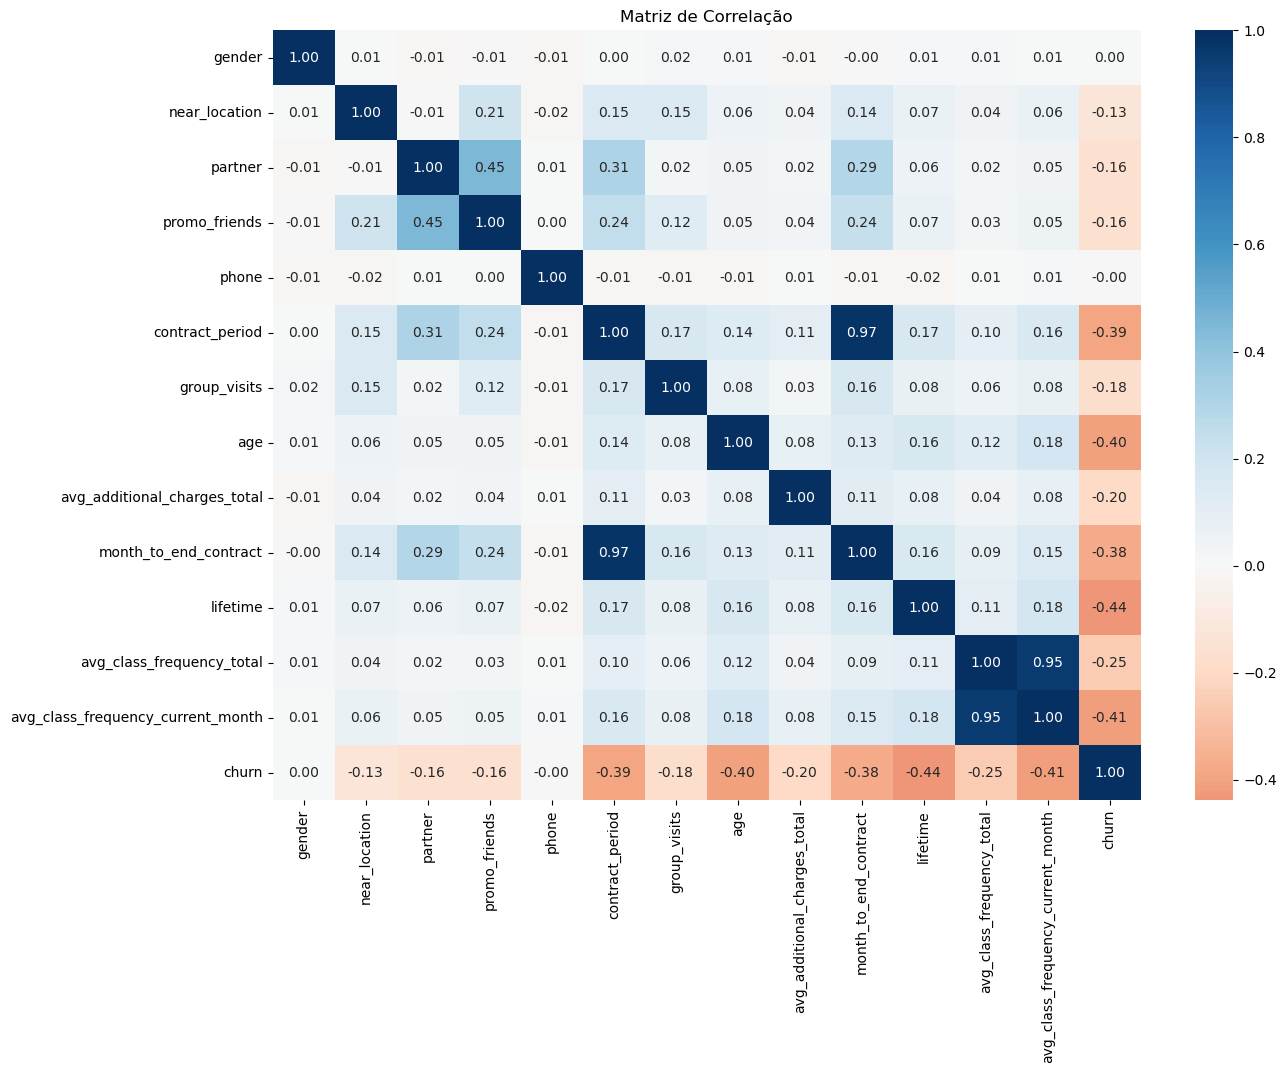

In [23]:
# Calculando a matriz de correlação
plt.figure(figsize=(14, 10))
corr_matrix = df_gym_churn.corr()

# Criando o heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu', center=0)
plt.title('Matriz de Correlação')
plt.show()

**Observações**: É possível observar alguns pontos interessantes na matriz dr correlação:
- **Multicolinearidade Detectada**: Veja a interseção entre `contract_period` e `month_to_end_contract` ($0.97$). Elas são praticamente a mesma informação e, portanto, apresentam alta colinearidade. Essas variáveis precisarão ser removidas de modelos de Regressão Logística. O mesmo ocorre entre `avg_class_frequency_total` e `avg_class_frequency_current_month` ($0.95$);
- **Principais Inimigos do Churn**: As correlações negativas mais fortes com o `churn` são `lifetime` ($-0.44$), `avg_class_frequency_current_month` ($-0.41$), `age` ($-0.40$) e `contract_period` ($-0.39$). Isso significa que quanto maiores forem esses valores, menor é a chance de o cliente sair;
- **Fatores Irrelevantes**: O `gender` (gênero) e o fato de ter fornecido o `phone` (telefone) têm correlação próxima de zero com a saída do cliente (`churn`).

## 4 Modelagem Preditiva
Através da utilização de modelagem e aprendizado de máquina, vamos tentar prever o `churn` do cliente. para isso, vamos utilizar dois algoritmos aqui: Regressão Logística e Floresta Aleatória.

### 4.1 Preparação e Divisão dos Dados
Aqui faremos dois passos:
- Retirar as variáveis `month_to_end_contract` e `avg_class_frequency_total`, pois além das duas variáveis apresentarem alta colinearidade com `contract_period` e `avg_class_frequency_current_month`, respectivamente, foram as variáveis que menos apresentaram correlação com o `churn` de cada par de variáveis;
- Dividir os dados em conjuntos de treino e teste, com 80% de dados para o conjunto de treino e 20% para o conjunto de teste.


In [24]:
# Removendo variáveis com alta colinearidade para evitar redundância
df_gym_clean = df_gym_churn.drop(['month_to_end_contract', 'avg_class_frequency_total'], axis=1)

print("Colunas restantes após a limpeza de colinearidade:")
print(df_gym_clean.columns.tolist())


Colunas restantes após a limpeza de colinearidade:
['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'contract_period', 'group_visits', 'age', 'avg_additional_charges_total', 'lifetime', 'avg_class_frequency_current_month', 'churn']


In [25]:
# Agora definimos X e y usando o dataframe limpo
X = df_gym_clean.drop('churn', axis=1)
y = df_gym_clean['churn']

# Dividindo em treino (80%) e validação (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Padronizando os dados
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)
X_test_st = scaler.transform(X_test)

# Lista de modelos
models = [
    LogisticRegression(solver='liblinear', random_state=0), # solver 'liblinear' é usado para conjuntos de dados binários
    RandomForestClassifier(n_estimators=100, random_state=0)
]

# Função para imprimir métricas
def make_prediction(m, X_train, y_train, X_test, y_test):
    model = m
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'Modelo: {m}')
    print(f'Acurácia: {accuracy_score(y_test, y_pred):.2f}')
    print(f'Precisão: {precision_score(y_test, y_pred):.2f}')
    print(f'Sensibilidade (Recall): {recall_score(y_test, y_pred):.2f}')
    print('---------------------------------')

# Executando a comparação
for i in models:
    make_prediction(i, X_train_st, y_train, X_test_st, y_test)
    

Modelo: LogisticRegression(random_state=0, solver='liblinear')
Acurácia: 0.90
Precisão: 0.79
Sensibilidade (Recall): 0.82
---------------------------------
Modelo: RandomForestClassifier(random_state=0)
Acurácia: 0.90
Precisão: 0.81
Sensibilidade (Recall): 0.75
---------------------------------


**Observações**: Embora os dois modelos tenham apresentado o mesmo valor de acurácia ($90\%$), a Regressão Logística se mostrou o melhor modelo pelas seguintes razões:
- A Sensibilidade da Regressão Logística é superior ($0.82$ vs $0.75$). No contexto de uma academia, é mais valioso identificar corretamente o maior número possível de clientes que pretendem sair, mesmo que isso signifique enviar uma oferta por engano para alguém que ficaria;
- A Regressão Logística manteve um equilíbrio melhor entre capturar os clientes que sairam (*Recall*) e manter a assertividade (Precisão);
- Além das métricas, a Regressão Logística é um modelo mais simples e menos propenso a sobreajuste (overfitting) do que a Floresta Aleatória em conjuntos de dados menores.

## 5 Agrupamento (Clustering)
Aqui deixamos de apenas prever o número de clientes que sairão e passamos a entender "quem são" os clientes através do Agrupamento (Clustering). O objetivo é identificar grupos com características semelhantes para que a Model Fitness possa criar campanhas de marketing personalizadas para cada grupo.

### 5.1 Padronização e Dendograma
O primeiro passo aqui é padronizar os dados para que a escala das variáveis não distorça as distâncias. Além disso, vamos construir um dendrograma para visualizar quantos grupos naturais existem nos dados.É importante destacar que no agrupamento, não incluímos a coluna churn, pois queremos que os grupos sejam formados pelo comportamento do cliente, e não pelo resultado final.

Para enteder agrupamento natural dos dados, vamos utilizar a função `linkage()`. Diferente de `KMeans()`, em que precisamos definir o número de grupos ($n = 5$), `linkage()` nos permite visualizar toda a estrutura de dados antes de decidirmos onde cortar a árvore. Além disso, usaremos o parâmetro `method = 'ward'`, já que o mesmo tende a criar grupos de tamanhos mais parecidos, o que seria ideal para criar retratos de usuários típicos.


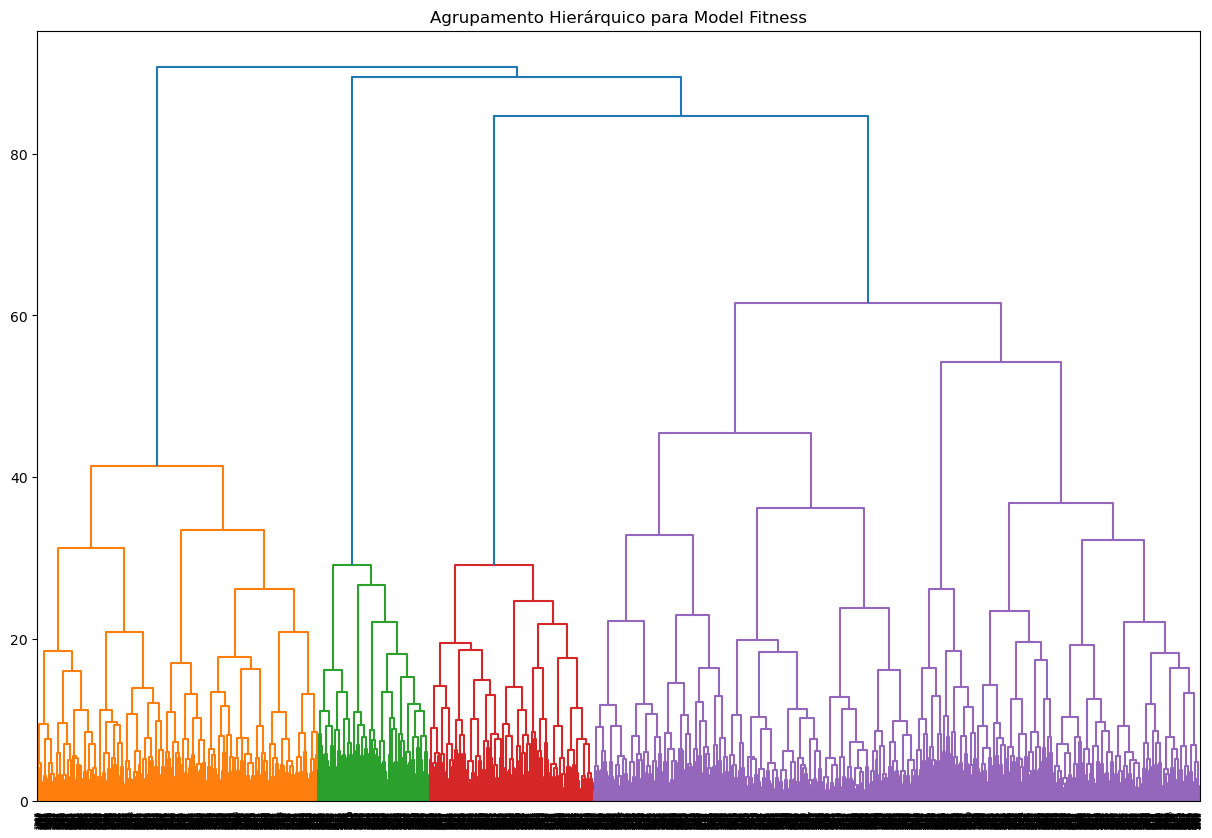

In [26]:
# 1. Padronizando os dados (usando o df_gym_clean sem colinearidade)
X_clustering = df_gym_clean.drop('churn', axis=1)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_clustering)

# 2. Construindo a matriz de distâncias
# O método 'ward' minimiza a variância dentro dos clusters
linked = linkage(X_sc, method='ward')

# 3. Plotando o dendrograma 
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Agrupamento Hierárquico para Model Fitness')
plt.show()


**Observações**: A partir do dendograma criado, é possível observar:
- Se traçássemos na altura da distância $y = 60$ no eixo vertical do dendograma, conseguiríamos observar que há ao menos $5$ ramos (representados pelas cores diferentes, mas dois dos ramos seriam de cor roxa). Isso indica que podemos usar $n = 5$ para `KMeans`;
- A parte muito densa na região inferior do gráfico mostra como os $4.000$ clientes são agrupados gradualmente até formarem esses $5$ grandes blocos.

### 5.2 Aplicando K-Means
Após visualizar o dendrograma, vamos aplicar o algoritmo `KMeans` para fixar os clientes em 5 grupos específicos.

In [27]:
# Definindo o modelo K-means com 5 clusters
km = KMeans(n_clusters=5, random_state=0)

# Aplicando aos dados padronizados (X_sc) 
labels = km.fit_predict(X_sc)

# Adicionando os rótulos ao dataframe para análise 
df_gym_clean['cluster'] = labels

# Calculando a média de cada característica por cluster
cluster_profiles = df_gym_clean.groupby('cluster').mean().sort_values(by='churn', ascending=False)

# Exibindo resultados
display(cluster_profiles)


,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,lifetime,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,
0,0.488372,1.000000,0.189624,0.071556,0.899821,1.820215,0.274597,27.516100,119.280256,1.949016,1.201961,0.582290
3,0.498333,0.000000,0.495000,0.075000,0.911667,2.963333,0.226667,28.681667,137.139130,2.778333,1.594682,0.408333
2,0.489855,0.995169,0.902415,1.000000,0.899517,6.965217,0.520773,29.590338,152.705310,3.728502,1.886617,0.129469
1,0.553590,1.000000,0.405827,0.007284,0.926119,6.570239,0.540062,30.802289,177.136345,3.533819,2.302468,0.032258
4,0.548951,0.951049,0.398601,0.234266,0.839161,4.856643,0.517483,29.853147,153.349944,13.279720,2.105894,0.000000


Para ajudar nas conclusões, vamos visualizar a média de `churn` por *cluster* e entender melhor cada grupo de maneira visual.

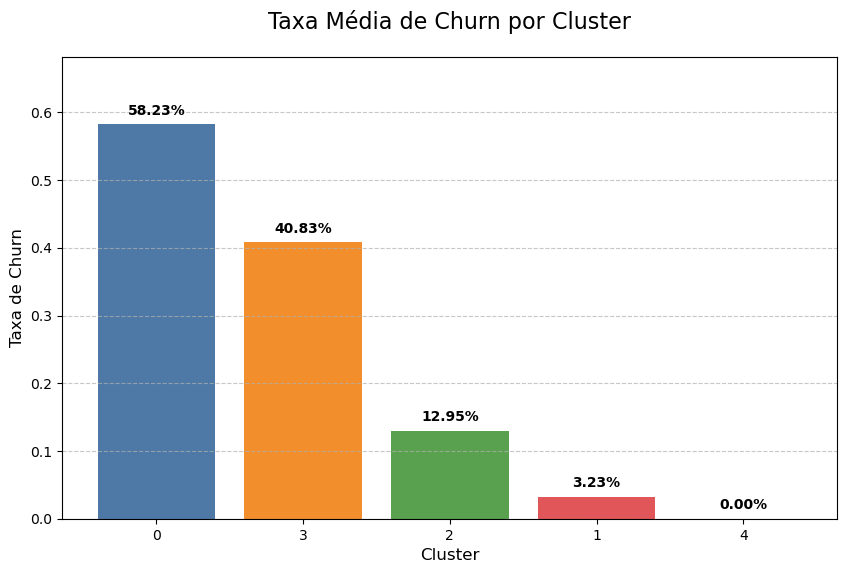

In [28]:
# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_profiles.index.astype(str), cluster_profiles['churn'], 
                color=['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1'])

# Configurações estéticas e de labels
plt.title('Taxa Média de Churn por Cluster', fontsize=16, pad=20)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Taxa de Churn', fontsize=12)

# Ajustando o limite do eixo Y para os rótulos caberem
plt.ylim(0, cluster_profiles['churn'].max() + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando os valores exatos acima das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

# Apresentando o gráfico
plt.show()


**Observações**: Diante da tabela de *clusters*, podemos descrever os 5 grupos da seguinte forma:
- **Cluster 4 - Clientes Retidos de Longo Prazo (Churn: $0\%$)**:
    - **Características**: Este segmento apresenta o maior lifetime médio ($13.28 meses$), indicando uma base consolidada. O `contract_period` de $4.86$ meses aliado à ausência de evasão sugere que, embora não utilizem exclusivamente planos anuais, possuem uma taxa de renovação orgânica de 100%;
    - **Perfil**: Clientes fidelizados com comportamento estável e alta previsibilidade de receita.
- **Cluster 1: Clientes de Alto Valor e Engajamento (Churn: $3\%$)** (Probabilidade residual de evasão):
    - **Características**: Apresentam o maior ticket médio de gastos extras (`avg_additional_charges_total` = $\$177.14$) e a maior intensidade de uso da infraestrutura (`avg_class_frequency_current_month` = $2.30$). A totalidade do grupo reside ou trabalha nas proximidades da unidade (`near_location` = $1.00$);
    - **Perfil**: Usuários "Power Users" que maximizam o uso dos serviços e geram receitas acessórias significativas.
- **Cluster 2: Clientes Vinculados a Parcerias e Redes (Churn: $13\%$)**:
    - **Características**: Caracterizado por uma forte dependência de canais de aquisição externos: $100\%$ via `promo_friends` e $90\%$ via programas `partner`. Possuem o maior `contract_period` médio ($6.97$ meses), refletindo a natureza dos contratos corporativos;
    - **Perfil**: Segmento com retenção sustentada por incentivos contratuais e laços sociais, apresentando risco moderado-baixo.
- **Cluster 3: Clientes com Barreira Logística (Churn: $41\%$)**:
    - **Características**: O diferencial estatístico deste grupo é o `near_location` nulo ($0.00$). A distância física correlaciona-se diretamente com a menor participação em atividades coletivas (`group_visits` = $0.23$) e uma frequência semanal reduzida ($1.59$);
    - **Perfil**: Clientes com alto risco de churn devido a fricção logística, independentemente da satisfação com o serviço.
- **Cluster 0: Clientes de Curto Prazo e Baixa Maturidade (Churn: $58\%$)**:
    - **Características**: É o grupo com os indicadores de engajamento mais frágeis: menor idade média ($27.5$ anos), menor tempo de permanência ($1.95$ meses) e menor frequência de treino ($1.20$ vezes/semana). O `contract_period` reduzido ($1.82$ meses) indica uma baixa intenção de compromisso a longo prazo no momento da adesão;
    - **Perfil**: Alunos em estágio de experimentação com alta volatilidade. Representam o alvo prioritário para políticas de retenção e engajamento preventivo.

## 6 Recomendações
Com base na segmentação de clientes realizada, propõe-se as seguintes ações para redução da taxa de churn:
- **Para o Grupo de Alto Risco (Cluster 0 - Churn 58%)**:
    - **Ação**: Implementar um programa de "Onboarding" e gamificação para novos alunos;
    - **Justificativa**: Este grupo apresenta o menor lifetime ($1.9$ meses) e a menor idade média. É crucial criar o hábito de treino nos primeiros 60 dias. Ofertas de aulas experimentais em grupo (`group_visits`) podem aumentar o engajamento inicial.
- **Para o Grupo com Barreira Logística (Cluster 3 - Churn 41%)**:
    - **Ação**: Oferecer planos de fidelidade de longo prazo com descontos agressivos ou parcerias de transporte/estacionamento;
    - **Justificativa**: A principal característica deste grupo é não residir ou trabalhar próximo à unidade. A distância é o fator determinante para a saída. Contratos anuais podem desestimular o abandono por conveniência momentânea.
- **Para o Grupo Social e Corporativo (Cluster 2 - Churn 13%)**:
    - **Ação**: Fortalecer campanhas de indicação (Amigo Indica Amigo) e eventos sociais exclusivos;
    - **Justificativa**: Este cluster é movido por conexões sociais (`promo_friends` e `partner`). O vínculo com amigos é o que sustenta a retenção, mesmo com frequências moderadas.
- **Para os Clientes de Elite e Veteranos (Clusters 1 e 4 - Baixo Churn)**:
    - **Ação**: Campanhas de *Upsell* e programas de fidelidade *VIP*;
    - **Justificativa**: São clientes estáveis e de alto gasto. O foco aqui deve ser o aumento do LTV (Lifetime Value) através da oferta de serviços premium (personal trainer, suplementação, massoterapia).

## 7 Conclusão
O projeto utilizou técnicas de Ciência de Dados para analisar a rotatividade da rede Model Fitness. A análise exploratória revelou que a frequência de treinos no último mês e o tempo de contrato são os indicadores mais fortes de um churn iminente.

Através do algoritmo *K-Means*, foi possível segmentar a base de clientes em 5 perfis distintos, permitindo uma visão clara de onde os esforços de retenção devem ser concentrados. O modelo de classificação (Regressão Logística/Floresta Aleatória) mostrou-se eficaz na predição de novos casos de evasão, o que permite à gestão agir preventivamente.

Em suma, a estratégia de retenção deve ser diferenciada: focar em conveniência e logística para quem mora longe, engajamento e criação de hábito para os mais jovens/novatos, e fortalecimento de laços sociais para os clientes corporativos. A digitalização dos perfis dos clientes agora fornece à Model Fitness uma ferramenta baseada em evidências para maximizar a lealdade e a receita da rede.
